# Исследование стартапов: куда инвестировать в 2015 году

Учебный проект программы «Аналитик данных» (Яндекс Практикум), выполнен самостоятельно.
Стек: Python, pandas, matplotlib.

## Введение

**Контекст:** условно идёт 2015 год, инвестор хочет понять, в какой сегмент рынка и через какой тип финансирования вкладывать деньги. Есть исторические данные о финансировании стартапов и о возвратах средств.

**Цель:** провести исследовательский анализ финансирования компаний, найти тренды и дать рекомендацию по сегменту рынка и типу финансирования.

**Что сделано:**
1. Предобработка: названия столбцов, типы, даты, пропуски, дубликаты; восстановление `mid_funding_at`.
2. Новые признаки: группы по сроку финансирования, укрупнение рынков (массовые, средние, нишевые).
3. Выбросы по IQR внутри каждого рынка, отбор лет с 50+ раундами, сравнение типов финансирования.
4. Динамика размера раундов и числа раундов, растущие массовые сегменты, доля возвращённых средств по типам финансирования.
5. Итоговые выводы и рекомендации.

## Шаг 1. Загрузка и предобработка данных

**Данные:** учебные датасеты Яндекс Практикума на основе базы данных стартапов. Данные являются материалами курса и в репозиторий не входят.
- `cb_investments` (54 294 строки, 40 столбцов): компания, рынок, страна и город, статус, даты основания и раундов, число раундов, общий объём финансирования и суммы по типам финансирования и раундам;
- `cb_returns` (15 строк): суммы возвратов по типам финансирования по годам, млн долларов.

### 1.1. Общая информация

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/cb_investments.zip", sep=';', low_memory=False)

In [3]:
cb_returns = pd.read_csv("data/cb_returns.csv")

In [4]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_share': df.isna().mean() * 100
}).sort_values('missing_share', ascending=False)

,missing_count,missing_share
state_code,24133,44.448742
mid_funding_at,24006,44.214830
participants,23821,43.874093
founded_month,15812,29.122923
founded_quarter,15812,29.122923
founded_at,15740,28.990312
founded_year,15740,28.990312
city,10972,20.208494
country_code,10129,18.655837
region,10129,18.655837


In [7]:
cb_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [8]:
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


**Выводы по первичному осмотру**

1. Основной датасет: 54 294 строки и 40 столбцов.
2. Полностью заполненных столбцов нет (максимум 49 438 значений). Хуже всего заполнены `state_code`, `mid_funding_at` и `participants` — не хватает около 44% значений. В 27 финансовых столбцах ровно по 49 438 значений: около 4856 строк (9%) вообще без финансовой информации.
3. Даты хранятся как `object`, `founded_year` — как `float64`, `funding_total_usd` — как строка с разделителями-запятыми.
4. В названиях столбцов ` market ` и ` funding_total_usd ` есть лишние пробелы.

### 1.2. Предобработка данных

In [9]:
df.columns=df.columns.str.lower().str.replace(" ", "")

Названия столбцов приведены к нижнему регистру, пробелы удалены.

In [10]:
df['funding_total_usd']=pd.to_numeric(df['funding_total_usd'].str.replace(',', '', regex=False), errors='coerce')

- Названия столбцов приведены к нижнему регистру, удалены пробелы.
- В столбце `funding_total_usd` удалены запятые, тип данных изменен на числовой. Некорректные значения заменены на `NaN`.

In [11]:
df[['founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].head(15)

,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at
0,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06
1,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15
2,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14
5,1831-01-01,NaN,NaN,1831.0,2014-10-23,NaN,2014-10-23
6,1834-01-01,NaN,NaN,1834.0,2013-09-05,2013-09-05,2013-12-22
7,1838-01-01,NaN,NaN,1838.0,2014-01-12,NaN,2014-01-12
8,1838-01-01,NaN,NaN,1838.0,2014-09-30,NaN,2014-09-30
9,1840-01-01,NaN,NaN,1840.0,2007-10-01,2007-10-01,2008-03-01


In [12]:
for column in ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']:
    df[column]=pd.to_datetime(df[column], errors='coerce')

In [13]:
df['founded_month']=df['founded_at'].dt.month

In [14]:
df['founded_quarter']=df['founded_at'].dt.quarter

In [15]:
# нужно будет после работы в данных столбца с пропусками привести столбцы к int
for column in ['founded_month', 'founded_quarter', 'founded_year']:
    df[column]=df[column].astype('Int64')

In [16]:
# Вычисляем разницу между последней и первой датой, делим на 2 и прибавляем к первой дате
middle_date = df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2

# Заполняем пропуски этой вычисленной датой
df['mid_funding_at'] = df['mid_funding_at'].fillna(middle_date)

In [17]:
df[['founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].head()

,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at
0,NaT,<NA>,<NA>,1636,2014-01-06,2014-01-06,2014-01-06
1,1785-01-01,1,1,1785,2014-05-15,2014-05-15,2014-05-15
2,1802-07-19,7,3,1802,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,1,1,1817,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,1,1,1826,2014-01-14,2014-01-14,2014-01-14


In [18]:
df[['founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   founded_at        38553 non-null  datetime64[ns]
 1   founded_month     38553 non-null  Int64         
 2   founded_quarter   38553 non-null  Int64         
 3   founded_year      38554 non-null  Int64         
 4   first_funding_at  49428 non-null  datetime64[ns]
 5   mid_funding_at    49430 non-null  datetime64[ns]
 6   last_funding_at   49432 non-null  datetime64[ns]
dtypes: Int64(3), datetime64[ns](4)
memory usage: 3.1 MB


- Столбцы с датами (`founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at`) преобразованы в формат `datetime`.
- На основе столбца `founded_at` извлечены месяц (`founded_month`) и квартал (`founded_quarter`) основания.
- Тип данных в столбцах `founded_month`, `founded_quarter` и `founded_year` изменен на целочисленный (`Int64`).
- Пропуски в столбце `mid_funding_at` заполнены вычисленной средней датой (середина между первой и последней датой финансирования).

In [19]:
cb_returns=cb_returns.set_index('year')

In [20]:
cb_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


- В датасете `cb_returns` столбец `year` установлен в качестве индекса.

In [21]:
for column in ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']:
    df[column]=df[column].str.lower()
    df[column]=df[column].fillna('unknown')

In [22]:
df['category_list']=df['category_list'].str.strip('|')

In [23]:
df['market'] = df['market'].str.strip()

- Текстовые данные в столбцах `name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `state_code`, `region` и `city` приведены к нижнему регистру.
- Пропуски в этих же столбцах заполнены заглушкой `'unknown'`.
- В столбце `category_list` удалены символы `|` по краям строк.
- В столбце `market` удалены лишние пробелы в начале и конце строк.

In [27]:
df=df.drop_duplicates()

In [28]:
# 1. Считаем количество строк (после первого удаления дубликатов выше)
initial_row_count = len(df)

# 2. Ищем и удаляем дубликаты
duplicated_row_count = df.duplicated().sum()
df = df.drop_duplicates()

# 3. Ищем и удаляем пропуски в конкретном столбце
missing_funding_count = df['funding_total_usd'].isna().sum()
df = df.dropna(subset=['funding_total_usd'])

# 4. Считаем итоговое количество строк
final_row_count = len(df)

In [29]:
print(f'Количество строк до удаления дубликатов: {initial_row_count}')
print(f'Количество дублирующих строк: {duplicated_row_count}')
print(f'Удалено строк без данных о финансировании: {missing_funding_count}')
print(f'Количество строк после удаления дубликатов: {final_row_count}')

Количество строк до удаления дубликатов: 49439
Количество дублирующих строк: 0
Удалено строк без данных о финансировании: 8532
Количество строк после удаления дубликатов: 40907


- Первый вызов `drop_duplicates()` удалил 4855 полных дубликатов: это пустые строки без данных (54 294 → 49 439). Поэтому в отчёте выше счётчик дубликатов равен 0, а «до удаления» показывает уже 49 439 строк.
- Удалены 8532 строки без числового значения `funding_total_usd` (пропуск или значение, которое не удалось перевести в число).
- Итог: 40 907 строк.

In [32]:
df[['first_funding_at', 'last_funding_at', 'mid_funding_at']].head()

,first_funding_at,last_funding_at,mid_funding_at
0,2014-01-06,2014-01-06,2014-01-06
1,2014-05-15,2014-05-15,2014-05-15
2,2009-07-02,2009-07-02,2009-07-02
3,2013-11-21,2014-11-03,2013-11-21
4,2014-01-14,2014-01-14,2014-01-14


In [34]:
mid_na_count=df['mid_funding_at'].isna().sum()
print(f'Осталось пропусков: {mid_na_count}') 

Осталось пропусков: 1


In [35]:
df[df['mid_funding_at'].isna()]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
33041,nubank,https://www.nubank.com.br/,consumer internet|financial services,financial services,16300000.0,operating,bra,unknown,sao paulo,são paulo,...,0.0,0.0,14300000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- В `mid_funding_at` остался 1 пропуск: у этой компании нет дат финансирования для расчёта.

**Выводы по предобработке**

1. **Даты** переведены в `datetime`, месяц и квартал основания выделены и переведены в `Int64`; пропуски `mid_funding_at` заполнены серединой между первой и последней датой финансирования.
2. **Текст** приведён к нижнему регистру, лишние пробелы и символы `|` по краям удалены, пропуски в текстовых столбцах заполнены `unknown`.
3. **Строки:** из 54 294 удалены 4855 пустых дубликатов и 8532 строки без суммы финансирования. Осталось 40 907 строк (75% исходных). Удалённые строки не содержат главного показателя, без которого анализ финансирования невозможен.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

In [36]:
df=df.dropna(subset=['mid_funding_at']) 

In [37]:
# 1. Считаем разницу между датами в днях (переводим результат в дни с помощью .dt.days)
df['funding_days']=(df['last_funding_at'] - df['first_funding_at']).dt.days

# 2. Пишем функцию для распределения по категориям
def get_funding_group(days):
    if days == 0:
        return 'Единичное финансирование'
    elif days <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

In [38]:
# 3. Применяем функцию к нашему новому столбцу и создаем итоговый столбец
df['funding_category']=df['funding_days'].apply(get_funding_group)

In [39]:
df['funding_category'].unique()

array(['Единичное финансирование', 'Срок финансирования до года',
       'Срок финансирования более года'], dtype=object)

In [40]:
companies_pct=df['funding_category'].value_counts(normalize=True).sort_index() * 100
my_colors = ['red', 'green', 'gold']

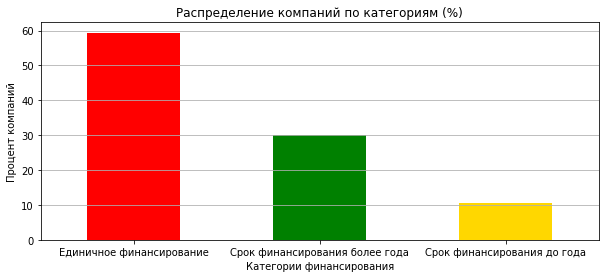

In [41]:
# Строим столбчатую диаграмму распределения по категориям
companies_pct.plot(
               kind='bar',
               rot=0,
               color=my_colors,
               legend=False, # Выключаем легенду
               title=f'Распределение компаний по категориям (%)',
               figsize=(10, 4)
)

# Настраиваем оформление графика
plt.xlabel('Категории финансирования')
plt.ylabel('Процент компаний')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

In [42]:
# Число уникальных компаний в каждой группе
companies_count = df.groupby('funding_category')['name'].nunique().reset_index()

# Переименуем столбцы
companies_count.columns = ['Группа финансирования', 'Количество компаний']

# Выводим результат
display(companies_count)

,Группа финансирования,Количество компаний
0,Единичное финансирование,24269
1,Срок финансирования более года,12281
2,Срок финансирования до года,4323


In [43]:
investments_pct=df.groupby('funding_category')['funding_total_usd'].sum().sort_index()

In [44]:
investments_pct=(investments_pct / investments_pct.sum()) * 100

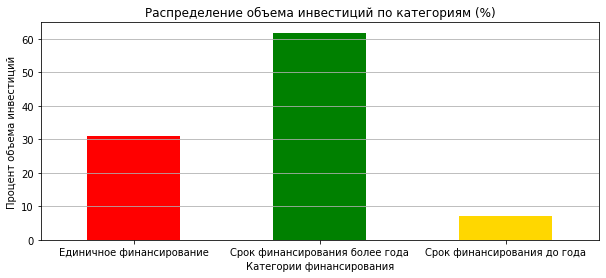

In [45]:
# Строим столбчатую диаграмму распределения по категориям
investments_pct.plot(
               kind='bar',
               rot=0,
               color=my_colors,
               legend=False, # Выключаем легенду
               title=f'Распределение объема инвестиций по категориям (%)',
               figsize=(10, 4)
)

# Настраиваем оформление графика
plt.xlabel('Категории финансирования')
plt.ylabel('Процент объема инвестиций')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

Сравнение распределений по числу компаний и по объёму денег:
- **по числу компаний:** около 59% компаний получили финансирование один раз, около 30% привлекали деньги дольше года, около 11% — до года;
- **по объёму денег:** на компании со сроком финансирования больше года приходится около 62% всех вложений, на единичное финансирование — около 31%, на срок до года — около 7%.

Основная часть денег уходит компаниям, которые привлекают раунды дольше года; большинство стартапов получают деньги один раз, и на них приходится меньшая доля капитала.

### 2.2 Выделение средних и нишевых сегментов рынка

In [46]:
# 1. Считаем сколько компаний в каждом сегменте столбца market
market_counts=df['market'].value_counts()

# 2. Пишем функцию для распределения по категориям
def get_market_segment(count):
    if count < 35:
        return 'Нишевый сегмент'
    elif count <= 120:
        return 'Средний сегмент'
    else:
        return 'Массовый сегмент'

In [47]:
# 3. Применяем функцию к нашему новому столбцу и создаем итоговый столбец
market_segments=market_counts.apply(get_market_segment)

In [48]:
result = market_segments.value_counts()
result

Нишевый сегмент     289
Средний сегмент      57
Массовый сегмент     49
Name: market, dtype: int64

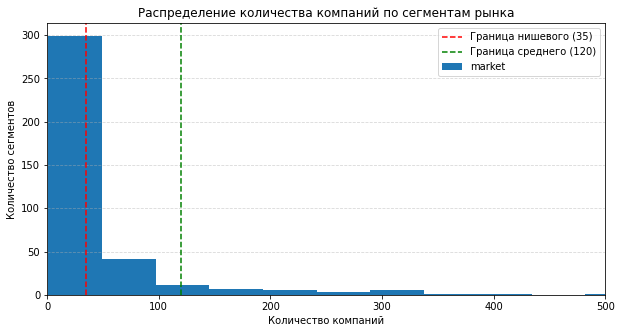

In [49]:
# Строим гистограмму нужного размера
market_counts.plot(kind='hist', 
                   bins=100, 
                   figsize=(10, 5))

# Рисуем границы для нишевого (35) и среднего (120) сегментов
plt.axvline(x=35, color='red', linestyle='--', label='Граница нишевого (35)')
plt.axvline(x=120, color='green', linestyle='--', label='Граница среднего (120)')

# Подписываем график и оси (базовым шрифтом)
plt.title('Распределение количества компаний по сегментам рынка')
plt.xlabel('Количество компаний')
plt.ylabel('Количество сегментов')

# Добавляем легенду
plt.legend()

# Добавляем сетку для удобства
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Приближаем левую часть графика, чтобы разглядеть линии отсечения
plt.xlim(0, 500) 

# Выводим график
plt.show()

Рынки разбиты на три группы по числу компаний: нишевые (до 35), средние (35–120) и массовые (больше 120).

- нишевых рынков 289;
- средних — 57;
- массовых — 49.

Распределение сильно скошено вправо: много мелких ниш с несколькими компаниями и немного крупных рынков с сотнями компаний.

In [50]:
# 1. Считаем рынки
counts = df['market'].value_counts()

# 2. Собираем списки названий (индексы) для замены
niche_names = counts[counts < 35].index
mid_names = counts[(counts >= 35) & (counts <= 120)].index

# 3. Меняем названия в таблице
df.loc[df['market'].isin(niche_names), 'market'] = 'niche'
df.loc[df['market'].isin(mid_names), 'market'] = 'mid'

# 4. Проверяем результат
df['market'].value_counts().head(10)

software               4812
mid                    3840
biotechnology          3590
unknown                2503
mobile                 2344
e-commerce             1866
curated web            1693
enterprise software    1381
health care            1185
clean technology       1180
Name: market, dtype: int64

Нишевые рынки объединены в `niche`, средние — в `mid`. После замены `mid` занимает второе место (3840 компаний); крупнейшие отдельные рынки — `software` (4812), `biotechnology` (3590) и `mobile` (2344).

**Выводы по шагу 2**

1. **Сроки финансирования:** по числу компаний лидирует единичное финансирование (около 59%), а по объёму денег — компании, которые привлекают средства дольше года (около 62% всех вложений).
2. **Рынки:** 289 нишевых и 57 средних рынков объединены в группы `niche` и `mid`; для детального анализа остаются 49 массовых рынков, крупнейшие — `software`, `biotechnology` и `mobile`.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

In [51]:
df['funding_total_usd'].describe()

count    4.090600e+04
mean     1.591252e+07
std      1.686809e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

- Среднее (около 15,9 млн $) почти в 8 раз больше медианы (2 млн $): несколько очень крупных сделок сильно тянут среднее вверх.
- Максимум — около 30 млрд $, явная аномалия.

Поэтому для типичного стартапа ориентируемся на медиану, а выбросы отсечём по межквартильному размаху.

In [52]:
# Рассчитываем 1 и 3 квартили
q1 = df['funding_total_usd'].quantile(0.25)
q3 = df['funding_total_usd'].quantile(0.75)

In [53]:
# Считаем размах и верхнюю границу
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

In [54]:
print('Нижняя граница: 0') # деньги не могут быть меньше нуля
print('Верхняя граница:', round(upper_bound))

Нижняя граница: 0
Верхняя граница: 24475000


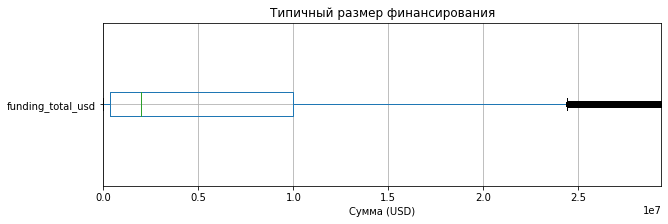

In [55]:
# Строим диаграмму размаха встроенным методом pandas
df.boxplot(column='funding_total_usd', vert=False, figsize=(10, 3))

# Ограничиваем ось X, чтобы обрезать миллиардные выбросы и разглядеть сам ящик
plt.xlim(0, upper_bound * 1.2) 

plt.title('Типичный размер финансирования')
plt.xlabel('Сумма (USD)')
plt.show()

По IQR типичный объём финансирования — от 0 до 24 475 000 $ (около 24,5 млн). Значения выше границы считаются выбросами; на диаграмме размаха их много, они сливаются в сплошную линию справа.

In [56]:
# 1. Считаем верхнюю границу типичных значений (IQR) ДЛЯ КАЖДОГО сегмента рынка
q1_market = df.groupby('market')['funding_total_usd'].quantile(0.25)
q3_market = df.groupby('market')['funding_total_usd'].quantile(0.75)

In [57]:
iqr_market = q3_market - q1_market
upper_bounds = q3_market + 1.5 * iqr_market

In [58]:
# 2. Добавляем рассчитанные границы в основную таблицу
# Метод map подставит нужную границу каждому стартапу в зависимости от его рынка
df['market_upper_bound'] = df['market'].map(upper_bounds)

In [59]:
# 3. Определяем компании с аномальным объемом финансирования
# Создаем колонку с булевыми значениями: True (если аномалия) / False (если норма)
df['is_anomaly'] = df['funding_total_usd'] > df['market_upper_bound']

In [60]:
# Посмотрим, сколько всего таких компаний получилось
print(f"Всего выявлено аномальных компаний: {df['is_anomaly'].sum()}")

Всего выявлено аномальных компаний: 5244


In [61]:
# 4. Считаем долю аномалий по сегментам
# Так как True = 1, а False = 0, среднее значение (.mean()) даст нам ровно долю аномалий!
anomaly_share = df.groupby('market')['is_anomaly'].mean() * 100

In [62]:
# 5. Выводим ТОП сегментов с наибольшей долей аномалий
top_anomalies = anomaly_share.sort_values(ascending=False).head(10)

print("Топ сегментов рынка с наибольшей долей аномального финансирования (%):")
print(top_anomalies.round(2))

Топ сегментов рынка с наибольшей долей аномального финансирования (%):
market
real estate        17.20
entertainment      16.67
consulting         16.62
search             16.49
cloud computing    16.45
saas               16.18
photography        16.18
technology         15.97
video              15.96
niche              15.90
Name: is_anomaly, dtype: float64


Границы выбросов рассчитаны отдельно для каждого рынка, так как типичные суммы в разных отраслях различаются.

1. Аномально крупное финансирование для своего рынка получили 5244 компании.
2. Больше всего таких компаний в `real estate` (17,2%), `entertainment` (16,7%) и `consulting` (16,6%).

Эти компании дальше исключаются, чтобы анализировать типичный рынок.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

In [63]:
# 1. Проверяем данные за 2014 год
# Смотрим самую последнюю дату финансирования
max_date = df['mid_funding_at'].max()
print('Самая последняя дата в датасете:', max_date.date())

Самая последняя дата в датасете: 2014-12-31


In [64]:
# Смотрим, за все ли месяцы 2014 года есть данные
data_2014 = df[df['mid_funding_at'].dt.year == 2014]
months_2014 = data_2014['mid_funding_at'].dt.month.value_counts().sort_index()
print('\nКоличество записей по месяцам в 2014 году:')
print(months_2014)


Количество записей по месяцам в 2014 году:
1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
Name: mid_funding_at, dtype: int64


In [65]:
# Смотрим соизмеримость объема данных по годам (сравним последние 5 лет)
years_volume = df['mid_funding_at'].dt.year.value_counts().sort_index().tail(5)
print('\nДинамика количества записей по годам (последние 5 лет):')
print(years_volume)


Динамика количества записей по годам (последние 5 лет):
2010    4094
2011    4863
2012    6089
2013    8423
2014    6619
Name: mid_funding_at, dtype: int64


In [66]:
# 2. Исключаем аномалии
# Оставляем только те строки, где is_anomaly == False
df = df[df['is_anomaly'] == False]

# Удаляем столбцы, которые мы создали в 3.1, чтобы вернуть таблице чистый вид
df = df.drop(columns=['market_upper_bound', 'is_anomaly'])

In [67]:
# 3. Фильтруем годы (оставляем только те, где >= 50 раундов)
# Группируем по году (достаем его прямо из даты) и считаем сумму раундов
rounds_by_year = df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum()

In [68]:
# Получаем список лет, которые прошли проверку (>= 50)
good_years = rounds_by_year[rounds_by_year >= 50].index

In [69]:
# Оставляем в таблице только стартапы из "хороших" лет
df = df[df['mid_funding_at'].dt.year.isin(good_years)]

# Выводим результат
print('Список лет, оставшихся для анализа:', list(good_years))
print('Количество строк после всех очисток:', len(df))

Список лет, оставшихся для анализа: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Количество строк после всех очисток: 35588


**Выводы по границам периода**

1. **2014 год неполный:** последняя дата — 31.12.2014, но с января по октябрь в месяц приходится 497–740 записей, а в ноябре — 306, в декабре — 23. За 2014 год 6619 записей против 8423 в 2013. Поэтому в графиках годовой динамики 2014 год нужно учитывать с осторожностью.
2. **Выбросы** по рынкам удалены.
3. **Период:** условию 50+ раундов в год соответствуют 2000–2014 годы, более ранние записи отброшены.

Итог: 35 588 строк за 2000–2014 годы.

### 3.3. Анализ типов финансирования по объёму и популярности

In [70]:
# Столбцы с суммами по типам финансирования
columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
           'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
           'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

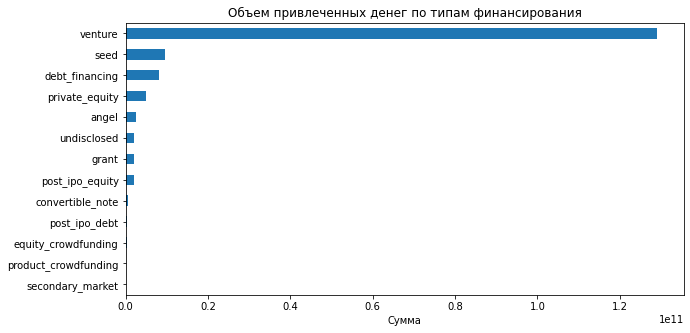

In [71]:
# График 1: Объем финансирования в сумме
df[columns].sum().sort_values().plot(kind='barh', figsize=(10, 5))
plt.title('Объем привлеченных денег по типам финансирования')
plt.xlabel('Сумма')
plt.show()

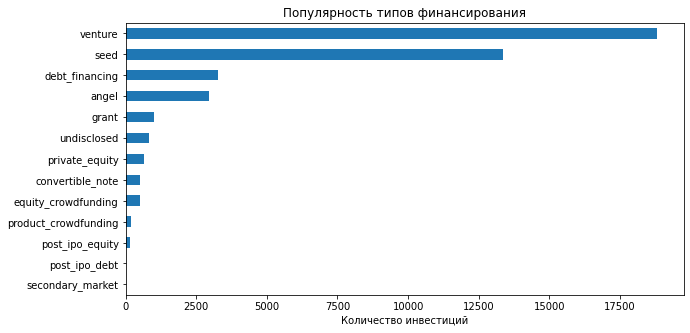

In [72]:
# График 2: Популярность (сколько раз встречаются)
(df[columns] > 0).sum().sort_values().plot(kind='barh', figsize=(10, 5))
plt.title('Популярность типов финансирования')
plt.xlabel('Количество инвестиций')
plt.show()

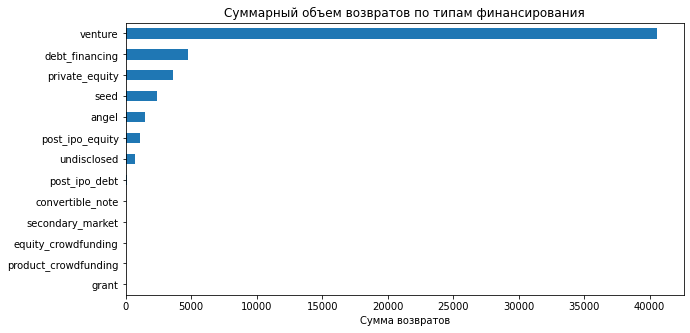

In [73]:
# Считаем сумму возвратов по каждому типу и строим график
cb_returns.sum().sort_values().plot(kind='barh', figsize=(10, 5))

plt.title('Суммарный объем возвратов по типам финансирования')
plt.xlabel('Сумма возвратов')
plt.show()

**Выводы по типам финансирования**

- **Объём вложений:** с большим отрывом лидирует `venture`; далее `seed`, `debt_financing` и `private_equity`.
- **Популярность (число инвестиций):** первое место у `venture`, второе у `seed`; далее `debt_financing` и `angel`.
- **Сумма возвратов:** также лидирует `venture`, далее `debt_financing`, `private_equity` и `seed`.

`venture` — самый массовый и самый крупный тип финансирования; `seed` популярен, но по объёму денег сильно уступает.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

In [74]:
# 1. Рассчитываем средний объём одного раунда для каждой компании
df['avg_per_round'] = df['funding_total_usd'] / df['funding_rounds']

In [75]:
# 2. Считаем типичный (медианный) размер одного раунда по годам
# Группируем прямо по году из даты
typical_funding_by_year = df.groupby(df['mid_funding_at'].dt.year)['avg_per_round'].median()

In [76]:
# 3. Считаем общее количество раундов (активность рынка) по годам
rounds_by_year = df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum()

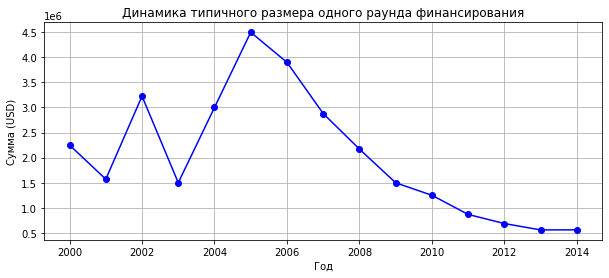

In [77]:
# Строим первый график (Динамика размера раунда)
plt.figure(figsize=(10, 4))
typical_funding_by_year.plot(kind='line', marker='o', color='blue')

plt.title('Динамика типичного размера одного раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Сумма (USD)')
plt.grid(True) 
plt.show()

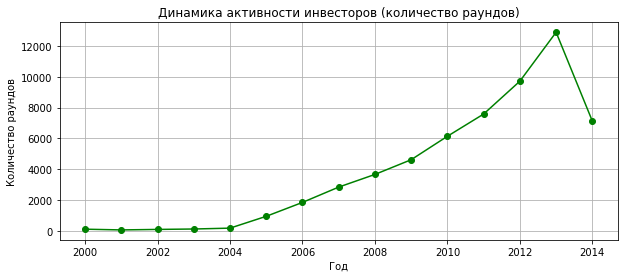

In [78]:
# Строим второй график (Динамика количества раундов)
plt.figure(figsize=(10, 4))
rounds_by_year.plot(kind='line', marker='o', color='green')

plt.title('Динамика активности инвесторов (количество раундов)')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid(True)
plt.show()

In [79]:
# Год с максимальным типичным размером раунда
print('Год с максимальным типичным размером раунда:', typical_funding_by_year.idxmax())

Год с максимальным типичным размером раунда: 2005


**Выводы по динамике финансирования**

1. **Типичный размер раунда:** медиана суммы на один раунд была максимальной в 2005 году (около 4,5 млн $), затем снижалась и в 2013–2014 годах составляет около 0,6 млн $.
2. **Число раундов** росло с 2005 по 2013 год (с ~1 тыс. до ~13 тыс.), в 2014 году — около 7 тыс. Это падение, скорее всего, связано с неполными данными за 2014 год, а не с реальным спадом.

### 4.2. Динамика финансирования массовых сегментов, выросших в 2014 году

In [80]:
# 1. Находим список массовых сегментов (где количество стартапов > 100)
market_counts = df['market'].value_counts()
mass_markets = market_counts[market_counts > 100].index

In [81]:
# 2. Строим сводную таблицу: сумма инвестиций по годам и сегментам
pivot_funding = df.pivot_table(
    index=df['mid_funding_at'].dt.year, 
    columns='market', 
    values='funding_total_usd', 
    aggfunc='sum'
)

In [82]:
# Заполняем пропуски нулями (если в какой-то год сегмент не получал денег)
pivot_funding = pivot_funding.fillna(0)

In [83]:
# 3. Отбираем сегменты, которые выросли в 2014 году по сравнению с 2013, а также исключаем заглушки, создавая новый список
bad_segments = ['unknown', 'mid', 'niche']

growing_mass_markets = []

for market in pivot_funding.columns:
    if (market in mass_markets) and (market not in bad_segments):
        if pivot_funding.loc[2014, market] > pivot_funding.loc[2013, market]:
            growing_mass_markets.append(market)

In [84]:
# 4. Оставляем в таблице только нужные сегменты и адекватные годы (например, 2005-2013)
# 2014 год исключаем из графика, так как он неполный
plot_data = pivot_funding.loc[2005:2013, growing_mass_markets]

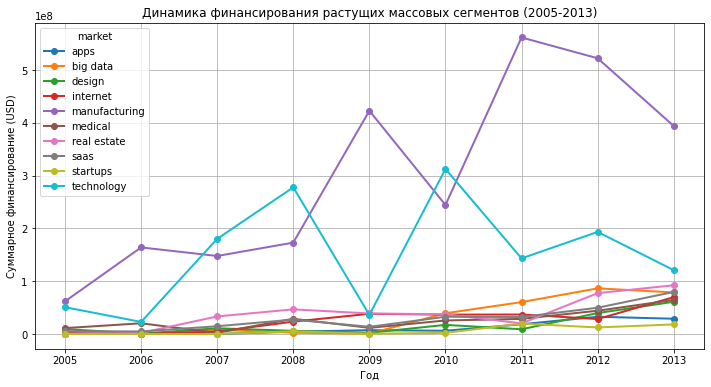

In [85]:
# 5. Строим график
plot_data.plot(figsize=(12, 6), marker='o', linewidth=2, grid=True)

# Добавляем понятные подписи
plt.title('Динамика финансирования растущих массовых сегментов (2005-2013)')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование (USD)')

# Показываем график
plt.show()

In [86]:
print("Отобранные сегменты:", growing_mass_markets)

Отобранные сегменты: ['apps', 'big data', 'design', 'internet', 'manufacturing', 'medical', 'real estate', 'saas', 'startups', 'technology']


**Выводы по растущим массовым сегментам**

- Рост суммарного финансирования в 2014 году относительно 2013 показали 10 сегментов: `apps`, `big data`, `design`, `internet`, `manufacturing`, `medical`, `real estate`, `saas`, `startups`, `technology`. Учитывая неполноту 2014 года, рост в этих сегментах — сильный сигнал.
- По объёму денег в 2005–2013 годах выделяются `manufacturing` (максимум в 2011 году, около 560 млн $) и `technology`, но их динамика неровная, с резкими скачками.
- Устойчивый рост в 2010–2013 годах при меньших суммах видно у `big data`, `saas`, `real estate`, `internet` и `medical`; `apps` почти не растёт.

Отбор массовых сегментов здесь сделан по порогу больше 100 компаний (на шаге 2 порог был 120), а суммы рассчитаны после удаления выбросов.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

In [87]:
# 1. Подготавливаем вложения (инвестиции)
df['year'] = df['mid_funding_at'].dt.year

# Группируем по году и суммируем только нужные финансовые колонки
investments_by_year = df.groupby('year')[columns].sum()

In [88]:
# 2. Подготавливаем возвраты (переводим миллионы в обычные доллары)
cb_returns_usd = cb_returns * 1000000

In [89]:
# 3. Считаем нормированную долю возврата
shares = cb_returns_usd / (investments_by_year + 1e-60)

In [90]:
# 4. Отбрасываем аномалии (выбросы) для каждого столбца методом квартилей
for col in shares.columns:
    q1 = shares[col].quantile(0.25)
    q3 = shares[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    
    # Заменяем значения, превышающие верхнюю границу, на пустоту (None)
    shares.loc[shares[col] > upper_bound, col] = None

In [91]:
# 5. Строим график для основных типов финансирования
target_cols = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

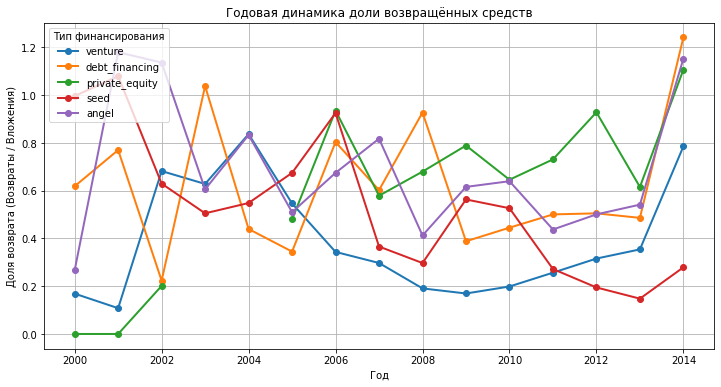

In [92]:
shares[target_cols].plot(figsize=(12, 6), marker='o', linewidth=2)

plt.title('Годовая динамика доли возвращённых средств')
plt.xlabel('Год')
plt.ylabel('Доля возврата (Возвраты / Вложения)')
plt.grid(True)
plt.legend(title='Тип финансирования')
plt.show()

**Выводы по доле возвращённых средств**

Доля возврата = возвраты / вложения по году и типу финансирования (вложения — после удаления выбросов, выбросы самой доли по IQR убраны).

- **`private_equity`:** с 2007 по 2012 год доля возврата в целом растёт (с ~0,6 до ~0,9), это самый устойчивый рост среди рассмотренных типов.
- **`venture`:** доля снижалась с 2002 по 2009 год (с ~0,7 до ~0,2) и затем медленно растёт.
- **`seed`, `angel`, `debt_financing`:** сильные колебания от года к году.

В 2014 году доля возврата резко растёт у всех типов, но вложения за этот год неполные, поэтому значение 2014 года завышено.

## Шаг 5. Итоговые выводы и рекомендации

### Рекомендации инвестору на 2015 год

1. **Сегмент рынка.** Обратить внимание на массовые сегменты, где финансирование росло в 2014 году и устойчиво росло в 2010–2013: `big data`, `saas`, `internet`, `real estate`, `medical`. Крупнейшие по объёму `manufacturing` и `technology` тоже выросли в 2014 году, но их динамика нестабильна.
2. **Тип финансирования.** `private_equity` показывает самый устойчивый рост доли возвращённых средств в 2007–2012 годах. Ранние стадии (`seed`, `angel`) дают сильно колеблющийся возврат.

### Что сделано

1. **Предобработка:** из 54 294 строк после удаления пустых дубликатов и строк без суммы финансирования осталось 40 907; даты приведены к `datetime`, пропуски `mid_funding_at` восстановлены.
2. **Новые признаки:** компании разделены по сроку финансирования, около 400 рынков укрупнены в массовые, средние и нишевые.
3. **Выбросы:** по IQR внутри каждого рынка удалены 5244 компании с аномально крупным финансированием; оставлены 2000–2014 годы (35 588 строк).
4. **Анализ:** динамика размера и числа раундов, растущие сегменты, доля возвращённых средств по типам финансирования.

### Главные выводы

- Около 59% компаний получают финансирование один раз, но около 62% денег уходит компаниям, которые привлекают средства дольше года.
- Типичный объём финансирования — до 24,5 млн $; доля выбросов выше всего в `real estate`, `entertainment` и `consulting`.
- `venture` лидирует по объёму, числу сделок и сумме возвратов, но его доля возврата в 2002–2009 годах снижалась, а у `private_equity` в 2007–2012 годах росла: абсолютные объёмы и относительная доходность дают разную картину.

**Ограничения:** данные за 2014 год неполные; доля возврата рассчитана на данных без выбросов; выводы о сегментах сделаны по графику без статистической проверки.